#Dataset for MLC

In [ ]:
import pandas as pd

# Creating the dataset
data = {
    "news": [
        "AI technology is transforming industries worldwide.",
        "New policies introduced for climate change awareness.",
        "Sports events, economic growth, political debates, and global crises discussed.",
        "Researchers discover a new species in the Amazon rainforest.",
        "Stock markets see a sudden rise amid economic stability.",
        "Latest smartphone released with innovative AI features.",
        "Hollywood movie wins multiple awards at the international film festival.",
        "Medical experts warn about the rising cases of heart disease.",
        "SpaceX successfully launches a new satellite into orbit.",
        "Cricket team secures a historic win in the world championship."
    ],
    "category": [
        ["Artificial Intelligence"],
        ["Environment", "Policy", "Awareness"],
        ["Sports", "Economy", "Politics", "World Affairs"],
        [],
        ["Economy", "Finance"],
        ["Technology", "Gadgets"],
        ["Entertainment", "Awards"],
        ["Health"],
        ["Space", "Technology"],
        ["Sports"]
    ]
}

# Creating a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df)


                                                news  \
0  AI technology is transforming industries world...   
1  New policies introduced for climate change awa...   
2  Sports events, economic growth, political deba...   
3  Researchers discover a new species in the Amaz...   
4  Stock markets see a sudden rise amid economic ...   
5  Latest smartphone released with innovative AI ...   
6  Hollywood movie wins multiple awards at the in...   
7  Medical experts warn about the rising cases of...   
8  SpaceX successfully launches a new satellite i...   
9  Cricket team secures a historic win in the wor...   

                                     category  
0                   [Artificial Intelligence]  
1            [Environment, Policy, Awareness]  
2  [Sports, Economy, Politics, World Affairs]  
3                                          []  
4                          [Economy, Finance]  
5                       [Technology, Gadgets]  
6                     [Entertainment, Awards]  

In [ ]:
from IPython.display import display

display(df)  # Jupyter Notebook ke liye best visualization


,news,category
0,AI technology is transforming industries world...,[Artificial Intelligence]
1,New policies introduced for climate change awa...,"[Environment, Policy, Awareness]"
2,"Sports events, economic growth, political deba...","[Sports, Economy, Politics, World Affairs]"
3,Researchers discover a new species in the Amaz...,[]
4,Stock markets see a sudden rise amid economic ...,"[Economy, Finance]"
5,Latest smartphone released with innovative AI ...,"[Technology, Gadgets]"
6,Hollywood movie wins multiple awards at the in...,"[Entertainment, Awards]"
7,Medical experts warn about the rising cases of...,[Health]
8,SpaceX successfully launches a new satellite i...,"[Space, Technology]"
9,Cricket team secures a historic win in the wor...,[Sports]


In [ ]:
# Exploratory Data Analysis (EDA)
print("Dataset Info:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   news      10 non-null     object
 1   category  10 non-null     object
dtypes: object(2)
memory usage: 292.0+ bytes
Dataset Info:
 None


In [ ]:
# Calculate category distribution
category_counts = df["category"].apply(lambda x: len(x)).value_counts()

# Print category distribution
print("\nCategory Distribution:\n", category_counts)



Category Distribution:
 category
2    4
1    3
3    1
4    1
0    1
Name: count, dtype: int64


In [ ]:
# Generate explanation
for count, num_samples in category_counts.items():
    if count == 0:
        print(f"There is {num_samples} sample record (4th) in which there is no category (empty list []).")
    elif count == 1:
        print(f"There are {num_samples} records where there is only 1 category.")
    elif count == 2:
        print(f"There are {num_samples} records where there are 2 categories.")
    elif count == 3:
        print(f"There is {num_samples} record where there are 3 categories.")
    elif count == 4:
        print(f"There is {num_samples} record where there are 4 categories.")


There are 4 records where there are 2 categories.
There are 3 records where there is only 1 category.
There is 1 record where there are 3 categories.
There is 1 record where there are 4 categories.
There is 1 sample record (4th) in which there is no category (empty list []).


<ipython-input-6-c1d82e7ed049>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


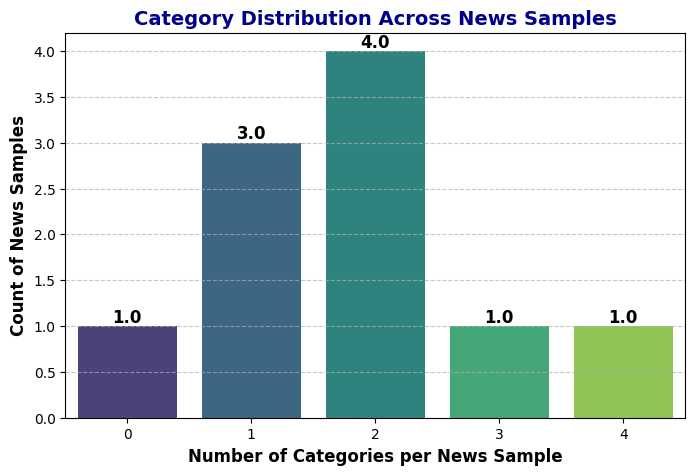

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Category Distribution
category_counts = df["category"].apply(lambda x: len(x)).value_counts()

# Plot count distribution
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")

# Add annotations (text labels on bars)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("Number of Categories per News Sample", fontsize=12, fontweight="bold")
plt.ylabel("Count of News Samples", fontsize=12, fontweight="bold")
plt.title("Category Distribution Across News Samples", fontsize=14, fontweight="bold", color="darkblue")

# Add grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


<ipython-input-7-4accf605f1c6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


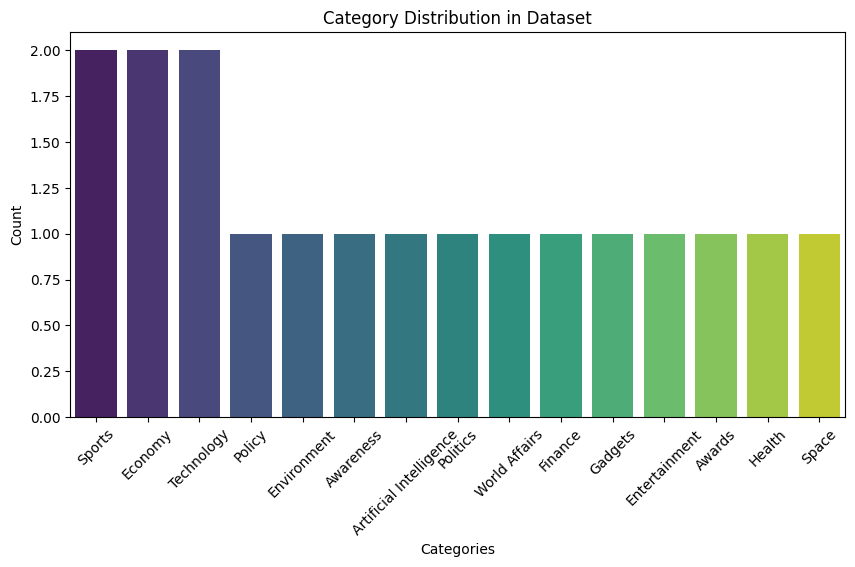

In [ ]:

# Visualizing category distribution
category_counts = df.explode("category")["category"].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Categories")
plt.ylabel("Count")
plt.title("Category Distribution in Dataset")
plt.show()



#**Checking records where there is no Category**

In [ ]:
# Checking for null values (including empty lists)
missing_values = df["category"].apply(lambda x: len(x) == 0).sum()
print("Number of missing (empty) values in category column:", missing_values)


Number of missing (empty) values in category column: 1


In [ ]:
# Find indices where category is empty
empty_category_indices = df[df["category"].apply(lambda x: len(x) == 0)].index

# Print the result
if len(empty_category_indices) > 0:
    print("The following news records have an empty category list:")
    for idx in empty_category_indices:
        print(f"Index {idx}: {df.loc[idx, 'news']}")
else:
    print("No news record has an empty category list.")


The following news records have an empty category list:
Index 3: Researchers discover a new species in the Amazon rainforest.


<ipython-input-10-0cf501b7b808>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df.index, y=df["num_categories"], palette="coolwarm")


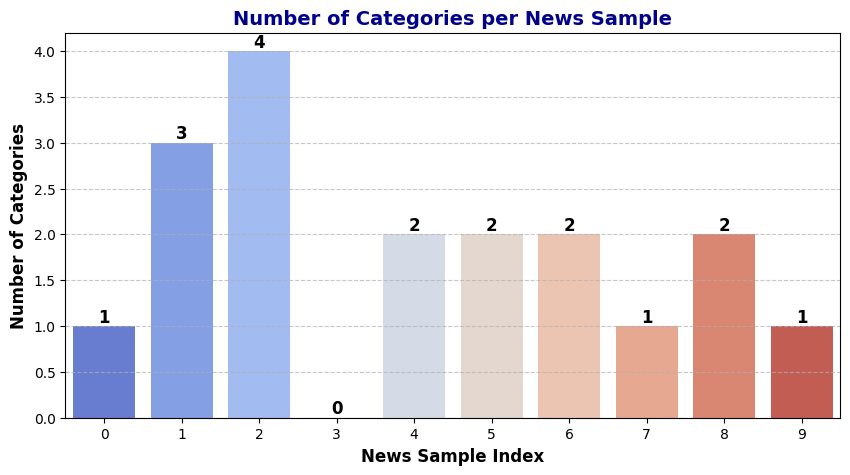

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate number of categories per news sample
df["num_categories"] = df["category"].apply(lambda x: len(x))

# Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=df.index, y=df["num_categories"], palette="coolwarm")

# Add annotations (labels on bars)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Labels and title
plt.xlabel("News Sample Index", fontsize=12, fontweight="bold")
plt.ylabel("Number of Categories", fontsize=12, fontweight="bold")
plt.title("Number of Categories per News Sample", fontsize=14, fontweight="bold", color="darkblue")

# Add grid for better readability
plt.xticks(df.index)  # Ensure x-axis has all indices
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()


#**Handling Null Values + must contain any 2 category**

In [ ]:
# Keep only records where category is NOT empty
df = df[df["category"].apply(lambda x: len(x) > 1)].reset_index(drop=True)

# Print updated DataFrame
print("Updated DataFrame after keeping only non-empty categories:")
display(df)


Updated DataFrame after keeping only non-empty categories:


,news,category,num_categories
0,new policy introduced climate change awareness,"[Environment, Policy, Awareness]",3
1,sport event economic growth political debate g...,"[Sports, Economy, Politics, World Affairs]",4
2,stock market see sudden rise amid economic sta...,"[Economy, Finance]",2
3,latest smartphone released innovative ai feature,"[Technology, Gadgets]",2
4,hollywood movie win multiple award internation...,"[Entertainment, Awards]",2
5,spacex successfully launch new satellite orbit,"[Space, Technology]",2


In [ ]:
df.columns

Index(['news', 'category', 'num_categories'], dtype='object')

In [ ]:
df.shape

(6, 3)

#**Appying NLP on News Column**

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download necessary NLP resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function for text preprocessing
def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove special characters & numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization (Corrected)
    tokens = word_tokenize(text)  # ✅ Now it correctly tokenizes each row, not the whole column

    # 4. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # 6. Join words back to sentence
    return " ".join(tokens)

# Apply preprocessing to News column
df["news"] = df["news"].apply(preprocess_text)

# Print cleaned data
display(df)

,news,category,num_categories
0,new policy introduced climate change awareness,"[Environment, Policy, Awareness]",3
1,sport event economic growth political debate g...,"[Sports, Economy, Politics, World Affairs]",4
2,stock market see sudden rise amid economic sta...,"[Economy, Finance]",2
3,latest smartphone released innovative ai feature,"[Technology, Gadgets]",2
4,hollywood movie win multiple award internation...,"[Entertainment, Awards]",2
5,spacex successfully launch new satellite orbit,"[Space, Technology]",2


#Tf_IDF on News Column for Featur Extraction (Converting Text into Matrix)

In [ ]:
#TFIDF on News Column ............................................ you can use tf-idf or /// Conutvectorizor
# Convert cleaned text into numerical features using TF-IDF
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(df["news"])
# Check the shape of X
print("Shape of News after TF_IDF:", features.shape)  # (num_samples, num_features)



Shape of News after TF_IDF: (6, 41)


In [ ]:

# Convert to Dense Matrix for Better Visualization
feature_names = vectorizer.get_feature_names_out()
dense_matrix = features.toarray()

# Create DataFrame for Better Visualization
tfidf_df = pd.DataFrame(dense_matrix, columns=feature_names)
print("\nTF-IDF Feature Representation:\n")
print(tfidf_df)


TF-IDF Feature Representation:

         ai      amid     award  awareness    change   climate   crisis  \
0  0.000000  0.000000  0.000000   0.419871  0.419871  0.419871  0.00000   
1  0.000000  0.000000  0.000000   0.000000  0.000000  0.000000  0.33957   
2  0.000000  0.361022  0.000000   0.000000  0.000000  0.000000  0.00000   
3  0.408248  0.000000  0.000000   0.000000  0.000000  0.000000  0.00000   
4  0.000000  0.000000  0.353553   0.000000  0.000000  0.000000  0.00000   
5  0.000000  0.000000  0.000000   0.000000  0.000000  0.000000  0.00000   

    debate  discussed  economic  ...  satellite       see  smartphone  \
0  0.00000    0.00000  0.000000  ...   0.000000  0.000000    0.000000   
1  0.33957    0.33957  0.278453  ...   0.000000  0.000000    0.000000   
2  0.00000    0.00000  0.296043  ...   0.000000  0.361022    0.000000   
3  0.00000    0.00000  0.000000  ...   0.000000  0.000000    0.408248   
4  0.00000    0.00000  0.000000  ...   0.000000  0.000000    0.000000   
5  

In [ ]:
#tHESE ARE OUR INPUT ATTRIBUTES
features=pd.DataFrame(features.toarray())
features

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,0.000000,0.000000,0.000000,0.419871,0.419871,0.419871,0.00000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.33957,0.33957,0.33957,0.278453,...,0.000000,0.000000,0.000000,0.000000,0.33957,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.361022,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.296043,...,0.000000,0.361022,0.000000,0.000000,0.00000,0.361022,0.361022,0.000000,0.361022,0.000000
3,0.408248,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.408248,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.353553,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.353553
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000,...,0.419871,0.000000,0.000000,0.419871,0.00000,0.000000,0.000000,0.419871,0.000000,0.000000


In [ ]:
num_of_feature=features.shape[1]
num_of_feature

41

#**Fearure SelectioN**

In [ ]:
#when u have more features and model overfits

In [ ]:
target=df['category']
target

,category
0,"[Environment, Policy, Awareness]"
1,"[Sports, Economy, Politics, World Affairs]"
2,"[Economy, Finance]"
3,"[Technology, Gadgets]"
4,"[Entertainment, Awards]"
5,"[Space, Technology]"


#Converting Target Variable into MLC

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
# Preprocessing: MultiLabel Binarization
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["category"])
targets=pd.DataFrame(y, columns=mlb.classes_)
display(targets)




,Awards,Awareness,Economy,Entertainment,Environment,Finance,Gadgets,Policy,Politics,Space,Sports,Technology,World Affairs
0,0,1,0,0,1,0,0,1,0,0,0,0,0
1,0,0,1,0,0,0,0,0,1,0,1,0,1
2,0,0,1,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,1,0
4,1,0,0,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,1,0,1,0


In [ ]:
# dataset=pd.concat([features,targets],axis=1)
# display(dataset)

In [ ]:
from sklearn.model_selection import train_test_split
# ✅ **Train-Test Split (80-20)**
xtrain, xtest, ytrain, ytest = train_test_split(features, targets, test_size=0.2, random_state=42)


In [ ]:
# ✅ **Display Shapes**
print("Training Features Shape:", xtrain.shape)
print("Testing Features Shape:", xtest.shape)
print("Training Labels Shape:", ytrain.shape)
print("Testing Labels Shape:", ytest.shape)

Training Features Shape: (4, 41)
Testing Features Shape: (2, 41)
Training Labels Shape: (4, 13)
Testing Labels Shape: (2, 13)


In [ ]:
y_train_array = np.array(ytrain)
y_test_array = np.array(ytest)

# Find valid labels (columns with at least two unique values)
valid_labels = [col for col in ytrain.columns if len(np.unique(ytrain[col])) > 1]

# Keep only valid labels
ytrain = ytrain[valid_labels]
ytest = ytest[valid_labels]

# Print shapes after filtering
print("Updated Training Labels Shape:", ytrain.shape)
print("Updated Testing Labels Shape:", ytest.shape)
print(xtrain.shape)

Updated Training Labels Shape: (4, 7)
Updated Testing Labels Shape: (2, 7)
(4, 41)


In [ ]:
from sklearn.preprocessing import StandardScaler
# ✅ **Feature Scaling (Standardization)**
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

#Applying MLC algo

# Logistic Regression

In [ ]:
pip install scikit-multilearn


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import hamming_loss, jaccard_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from skmultilearn.problem_transform import BinaryRelevance

In [ ]:
ytrain

,Awards,Economy,Entertainment,Finance,Gadgets,Space,Technology
5,0,0,0,0,0,1,1
2,0,1,0,1,0,0,0
4,1,0,1,0,0,0,0
3,0,0,0,0,1,0,1


In [ ]:
import numpy as np
import pandas as pd

# Convert y_train to a NumPy array if it's a DataFrame
y_train_array = np.array(ytrain)  # If it's a DataFrame, convert using .values

# Find labels with only one unique value
for i, col in enumerate(ytrain.columns):  # If it's a DataFrame
    unique_values = np.unique(ytrain[col])
    print(f"Label '{col}': Unique Values = {unique_values}")

# Alternative way to check all labels at once
single_class_labels = [col for col in ytrain.columns if len(np.unique(ytrain[col])) == 1]
print("Labels with only one class:", single_class_labels)


Label 'Awards': Unique Values = [0 1]
Label 'Economy': Unique Values = [0 1]
Label 'Entertainment': Unique Values = [0 1]
Label 'Finance': Unique Values = [0 1]
Label 'Gadgets': Unique Values = [0 1]
Label 'Space': Unique Values = [0 1]
Label 'Technology': Unique Values = [0 1]
Labels with only one class: []


In [ ]:
# Keep only labels that contain at least two unique values
valid_labels = [col for col in ytrain.columns if len(np.unique(ytrain[col])) > 1]

# Filter dataset
y_train = ytrain[valid_labels]
y_test = ytest[valid_labels]
y_train

,Awards,Economy,Entertainment,Finance,Gadgets,Space,Technology
5,0,0,0,0,0,1,1
2,0,1,0,1,0,0,0
4,1,0,1,0,0,0,0
3,0,0,0,0,1,0,1


In [ ]:

# Logistic Regression
lr = BinaryRelevance(LogisticRegression(solver='saga'))
lr.fit(xtrain, y_train)
y_pred_lr = lr.predict(xtest).toarray()

# Evaluation
print("\nLogistic Regression Results:")
print(f"Hamming Loss: {hamming_loss(ytest, y_pred_lr):.4f}")
print(f"Jaccard Score: {jaccard_score(ytest, y_pred_lr, average='samples'):.4f}")
print(f"F1 Score: {f1_score(ytest, y_pred_lr, average='samples'):.4f}")



Logistic Regression Results:
Hamming Loss: 0.1429
Jaccard Score: 0.0000
F1 Score: 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [ ]:
# Initialize Multi-Label Classifier with Random Forest
mlc_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=0))
# Train the model
mlc_model.fit(xtrain, ytrain)
# Predictions
ypred = mlc_model.predict(xtest)
ypred

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [ ]:
#Actual
ytest.to_numpy()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

In [ ]:
from sklearn.metrics import accuracy_score, hamming_loss, jaccard_score

# Classification Report
print("Classification Report:\n", classification_report(ytest, ypred))

# Hamming Loss (Lower is Better)
print("Hamming Loss:", hamming_loss(ytest, ypred))

# Jaccard Score (Higher is Better)
print("Jaccard Score:", jaccard_score(ytest, ypred, average='samples'))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         0

   micro avg       0.00      0.00      0.00         5
   macro avg       0.00      0.00      0.00         5
we

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me